In [70]:
import pandas as pd

#load the ds
df = pd.read_csv("/Users/mac1/Downloads/oil_sales_assignment_dataset - oil_sales_assignment_dataset.csv")

In [71]:
df.head()
df.tail()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
1995,TABUK,HM No 99317 GS-CENTER-TABUK MAIN RD TABUK,NAJDI CONSUMER,LARA,COCONUT,0.5L,LARA COCONUT 0.5L PREMIUM,31-40,2024,11,74.4,2.4,31.0
1996,AL AHSA,HM No 85390 GS-CENTER-AL AHSA MAIN RD AL AHSA,BLUE OASIS CO,LARA,SUNFLOWER,3L,LARA SUNFLOWER 3L,31-40,2022,5,20.0,0.5,40.0
1997,AL KHARJ,HM No 90740 GS-CENTER-AL KHARJ MAIN RD AL K...,NOVA FOODS,NOUR,SUNFLOWER,2.9L,NOUR SUNFLOWER 2.9L,91-100,2023,8,527.8,5.8,91.0
1998,RIYADH,HM No 52893 GS-CENTER-RIYADH MAIN RD RIYADH,NOVA FOODS,NAJMA,CORN,0.75L,NAJMA CORN 0.75L ECO,61-70,2024,6,305.0,5.0,61.0
1999,JEDDAH,HM No 73689 GS-CENTER-JEDDAH MAIN RD JEDDAH,NAJDI CONSUMER,BAYTNA,COCONUT,1.8L,BAYTNA COCONUT 1.8L ECO,101+,2022,4,181.8,1.8,101.0


In [72]:
print(len(df)) # print(shape[0])
print(df.shape[1])
print(df.info())



2000
13
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           2000 non-null   str    
 1   store_name     2000 non-null   str    
 2   manufacturer   2000 non-null   str    
 3   brand          2000 non-null   str    
 4   class          2000 non-null   str    
 5   size           2000 non-null   str    
 6   sku            2000 non-null   str    
 7   price_bracket  2000 non-null   str    
 8   year           2000 non-null   int64  
 9   month          2000 non-null   int64  
 10  value_sales    2000 non-null   float64
 11  volume_sales   2000 non-null   float64
 12  average_price  2000 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 203.2 KB
None


In [73]:
print(df.isnull().sum())

city             0
store_name       0
manufacturer     0
brand            0
class            0
size             0
sku              0
price_bracket    0
year             0
month            0
value_sales      0
volume_sales     0
average_price    0
dtype: int64


In [74]:
df.describe()

,year,month,value_sales,volume_sales,average_price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2022.990500,6.639500,614.839355,9.972100,60.990230
std,0.820211,3.468942,750.794991,9.862369,29.457029
min,2022.000000,1.000000,6.960000,0.500000,11.000000
25%,2022.000000,4.000000,132.000000,2.900000,37.337500
50%,2023.000000,7.000000,368.320000,7.000000,61.000000
75%,2024.000000,10.000000,794.100000,13.800000,81.000000
max,2024.000000,12.000000,6253.200000,81.700000,140.000000


In [75]:
from sklearn.preprocessing import LabelEncoder

# List of categorical columns
categorical_columns = [
    "city",
    "store_name",
    "manufacturer",
    "brand",
    "class",
    "size",
    "sku",
    "price_bracket"
]

# Create one LabelEncoder object
encoder = LabelEncoder()

# Encode each categorical column
for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print("Categorical columns encoded successfully!")
print(df.head())

Categorical columns encoded successfully!
   city  store_name  manufacturer  brand  class  size  sku  price_bracket  \
0     1         302             5      3      1     3  537              2   
1     2         237             6      4      0     1  648              4   
2     8        1487             0      0      3     3   93              0   
3     3        1832             6      5      2     2  864              6   
4     5         258             3      5      4     7  944              8   

   year  month  value_sales  volume_sales  average_price  
0  2024     12       830.86          30.1           27.6  
1  2024     10       373.10           9.1           41.0  
2  2023      1       171.70           1.7          101.0  
3  2022      2      1226.10          20.1           61.0  
4  2024      2       996.30          12.3           81.0  


Slope: 10.50790977366243
Intercept: -27.280591541652143
Equation: Value Sales = -27.28 + (10.51 × Average Price)
For every 1 unit increase in Average Price, Value Sales changes by 10.51 units.

Model Evaluation
----------------
Mean Squared Error: 454321.31970401155
Root Mean Squared Error: 674.0336191200047
R-squared: 0.13802212065425434


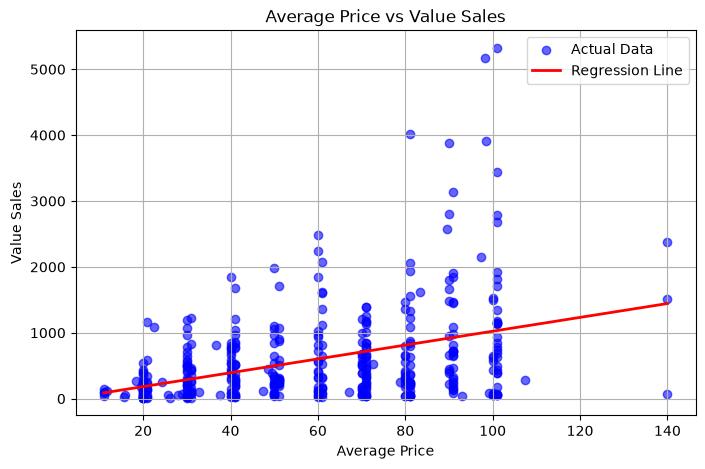

In [76]:
# ===========================================
# Import Libraries
# ===========================================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# ===========================================
# Prepare Features and Target
# ===========================================

# Independent Variable (Feature)
X = df[["average_price"]]

# Dependent Variable (Target)
y = df["value_sales"]


# ===========================================
# Split Dataset
# ===========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ===========================================
# Train Linear Regression Model
# ===========================================

model = LinearRegression()

model.fit(X_train, y_train)


# ===========================================
# Model Parameters
# ===========================================

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

print(
    f"Equation: Value Sales = {model.intercept_:.2f} + ({model.coef_[0]:.2f} × Average Price)"
)

print(
    f"For every 1 unit increase in Average Price, Value Sales changes by {model.coef_[0]:.2f} units."
)


# ===========================================
# Predictions
# ===========================================

y_pred = model.predict(X_test)


# ===========================================
# Model Evaluation
# ===========================================

mse = mean_squared_error(y_test, y_pred)
rmse_uni = np.sqrt(mse)
r2_uni = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("----------------")
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse_uni)
print("R-squared:", r2_uni)


# ===========================================
# Sort Data for Regression Line
# ===========================================

sorted_index = np.argsort(X_test["average_price"])

X_sorted = X_test.iloc[sorted_index]
y_sorted = y_pred[sorted_index]


# ===========================================
# Scatter Plot + Regression Line
# ===========================================

plt.figure(figsize=(8,5))

# Actual Data
plt.scatter(
    X_test,
    y_test,
    color="blue",
    alpha=0.6,
    label="Actual Data"
)

# Regression Line
plt.plot(
    X_sorted,
    y_sorted,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.title("Average Price vs Value Sales")
plt.xlabel("Average Price")
plt.ylabel("Value Sales")

plt.legend()

plt.grid(True)

plt.show()

In [77]:
# multivariant analysis
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [78]:
X = df[
    [
        "average_price",
        "volume_sales",
        "year",
        "month",
        "city",
        "manufacturer",
        "brand",
        "class",
        "price_bracket"
    ]
]

y = df["value_sales"]
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape) 


Feature Matrix Shape: (2000, 9)
Target Shape: (2000,)


In [79]:
# split the dataset into test and train

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Feature Matrix Shape:", X_train.shape)
print("Testing Feature Matrix Shape:", X_test.shape)

Training Feature Matrix Shape: (1600, 9)
Testing Feature Matrix Shape: (400, 9)


In [80]:
# Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Features standardized successfully!")
print(df)


Features standardized successfully!
      city  store_name  manufacturer  brand  class  size  sku  price_bracket  \
0        1         302             5      3      1     3  537              2   
1        2         237             6      4      0     1  648              4   
2        8        1487             0      0      3     3   93              0   
3        3        1832             6      5      2     2  864              6   
4        5         258             3      5      4     7  944              8   
...    ...         ...           ...    ...    ...   ...  ...            ...   
1995     9        1976             4      3      1     1  530              3   
1996     0        1435             2      3      3     9  607              3   
1997     2        1648             5      5      3     8  912              9   
1998     8         121             5      4      2     3  713              6   
1999     6         929             4      0      1     5   42              0   

   

In [81]:
# Train the Linear Regression model
model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [82]:
# Display all Intercept
print("Intercept:", model.intercept_)


Intercept: 617.1289937499998


In [83]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute Coefficient
1,volume_sales,626.818419,626.818419
0,average_price,295.369425,295.369425
4,city,10.495241,10.495241
8,price_bracket,-9.361265,9.361265
3,month,-8.327633,8.327633
7,class,-6.106760,6.106760
5,manufacturer,2.810432,2.810432
6,brand,1.813375,1.813375
2,year,0.426157,0.426157


In [84]:
# Predictions 

y_pred = model.predict(X_test_scaled)

# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
rmse_multi = np.sqrt(mse)
r2_multi = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse_multi)
print("R² Score:", r2_multi)


Model Evaluation
Mean Squared Error: 87892.84970355971
Root Mean Squared Error: 296.4672826865719
R² Score: 0.8332420493793089


In [85]:
comparison = pd.DataFrame({
    "Model": ["Univariate Linear Regression", "Multivariate Linear Regression"],
    "RMSE": [rmse_uni, rmse_multi],
    "R² Score": [r2_uni, r2_multi]
})

print(comparison)

                            Model        RMSE  R² Score
0    Univariate Linear Regression  674.033619  0.138022
1  Multivariate Linear Regression  296.467283  0.833242


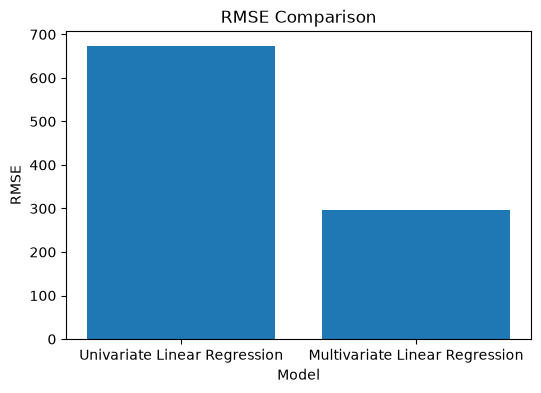

In [86]:

# comparing RMSE of both models using a bar chart
plt.figure(figsize=(6, 4))

plt.bar(
    
        comparison["Model"],
        comparison["RMSE"]
)

plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.xlabel("Model")

plt.show()

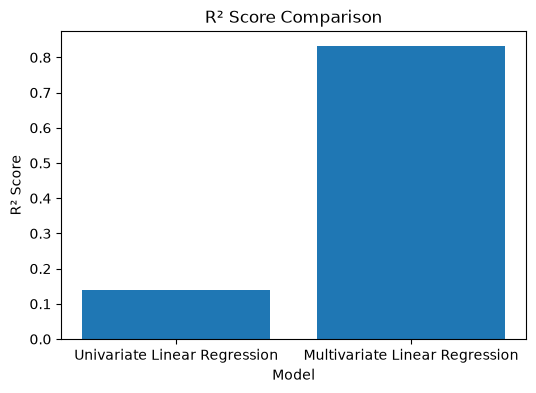

In [87]:

# comparing RMSE of both models using a bar chart
plt.figure(figsize=(6, 4))

plt.bar(
    
        comparison["Model"],
        comparison["R² Score"]
)

plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.xlabel("Model")

plt.show()

In [88]:
# Linear , One Hot, No scale
model = LinearRegression()

model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [89]:
# Predictions 

y_pred = model.predict(X_test)

# Evaluation Metrics
mse_lon = mean_squared_error(y_test, y_pred)
rmse_lon = np.sqrt(mse)
r2_lon = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("Mean Squared Error:", mse_lon)
print("Root Mean Squared Error:", rmse_lon)
print("R² Score:", r2_lon)


Model Evaluation
Mean Squared Error: 87892.84970355965
Root Mean Squared Error: 296.4672826865719
R² Score: 0.8332420493793091


In [94]:
# Linear , One Hot, Min-Max scale
from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

print("Min-Max Scaling applied successfully!")

Min-Max Scaling applied successfully!


In [95]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)
print("Model trained successfully!")

Model trained successfully!


In [105]:
# Predictions 

y_pred = model.predict(X_test_scaled)

# Evaluation Metrics
mse_lom = mean_squared_error(y_test, y_pred)
rmse_lom = np.sqrt(mse)
r2_lom = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("Mean Squared Error:", mse_lom)
print("Root Mean Squared Error:", rmse_lom)
print("R² Score:", r2_lom)
print(df.info())


Model Evaluation
Mean Squared Error: 87892.84970355977
Root Mean Squared Error: 296.4672826865719
R² Score: 0.8332420493793089
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           2000 non-null   int64  
 1   store_name     2000 non-null   int64  
 2   manufacturer   2000 non-null   int64  
 3   brand          2000 non-null   int64  
 4   class          2000 non-null   int64  
 5   size           2000 non-null   int64  
 6   sku            2000 non-null   int64  
 7   price_bracket  2000 non-null   int64  
 8   year           2000 non-null   int64  
 9   month          2000 non-null   int64  
 10  value_sales    2000 non-null   float64
 11  volume_sales   2000 non-null   float64
 12  average_price  2000 non-null   float64
dtypes: float64(3), int64(10)
memory usage: 203.2 KB
None


In [110]:
df = pd.read_csv("/Users/mac1/Downloads/oil_sales_assignment_dataset - oil_sales_assignment_dataset.csv")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           2000 non-null   str    
 1   store_name     2000 non-null   str    
 2   manufacturer   2000 non-null   str    
 3   brand          2000 non-null   str    
 4   class          2000 non-null   str    
 5   size           2000 non-null   str    
 6   sku            2000 non-null   str    
 7   price_bracket  2000 non-null   str    
 8   year           2000 non-null   int64  
 9   month          2000 non-null   int64  
 10  value_sales    2000 non-null   float64
 11  volume_sales   2000 non-null   float64
 12  average_price  2000 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 203.2 KB
None


In [108]:

numerical_columns = [
    "year",
    "month",
    "volume_sales",
    "average_price"
]

In [109]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        
        (
            "numerical",
            StandardScaler(),
            numerical_columns
        )
    ]
)


X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)


print("Encoding and scaling completed!")

ValueError: Some column names are not columns of the dataframe: {'size', 'store_name', 'sku'}

In [ ]:
model = LinearRegression()

model.fit(
    X_train_processed,
    y_train
)

print("Model trained successfully!")